In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Data ဖိုင်နှစ်ခုကိုဖတ်ရန်

url1 = "/content/drive/MyDrive/GCI global/telecom-20260520T093209Z-3-001/telecom/Client.csv"
url2 = "/content/drive/MyDrive/GCI global/telecom-20260520T093209Z-3-001/telecom/Record.csv"
client = pd.read_csv(url1)
record = pd.read_csv(url2)

# 2. Customer_ID နဲ့ ပေါင်းရန်
df = pd.merge(client, record, on='Customer_ID')

print(f"Original shape: {df.shape}")

# 3. Customer_ID ကိုဖယ်ရှားရန်
df = df.drop('Customer_ID', axis=1)

# 4. String column များကို Numeric အဖြစ်ပြောင်းရန် (Label Encoding)
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    if col != 'churn':  # churn က target ဖြစ်တယ်ဆိုရင် ခဏထား
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# 5. Missing value ဖြည့်ရန် (ဂဏန်းကော်လံတွေကိုပဲ)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 6. Target နဲ့ Features ခွဲရန်
target = 'churn'
X = df.drop(target, axis=1)
y = df[target]

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. XGBoost Model လေ့ကျင့်ရန်
model = XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# 9. Accuracy စစ်ဆေးရန်
acc = model.score(X_test, y_test)
print(f"\n✅ Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Original shape: (100000, 100)

✅ Accuracy: 0.6429 (64.28%)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = rf.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

Random Forest Accuracy: 0.6229 (62.29%)


In [ ]:
from sklearn.model_selection import GridSearchCV

# XGBoost အတွက် အကောင်းဆုံး parameter ရှာခြင်း
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,  # 3-fold cross validation (အမြန်ဆုံး)
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best XGB Accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# Test set မှာ စမ်းခြင့်
best_xgb = grid_search.best_estimator_
final_acc = best_xgb.score(X_test, y_test)
print(f"Final Test Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best XGB Accuracy: 0.6349 (63.49%)
Final Test Accuracy: 0.6428 (64.28%)


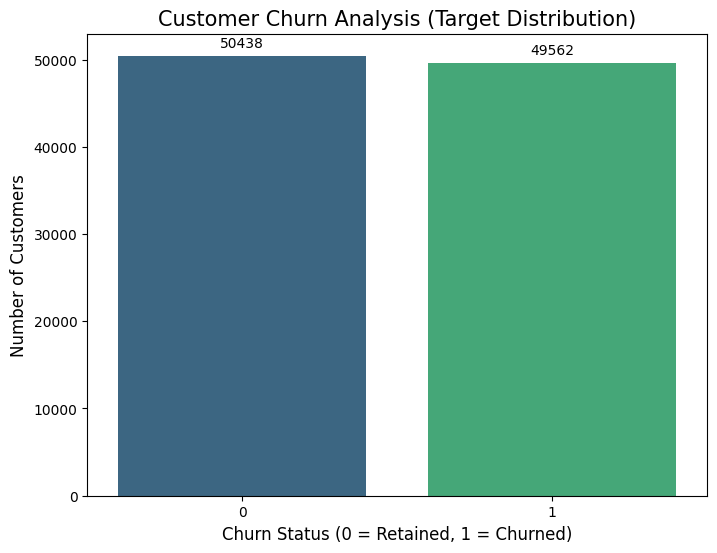

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Churn ဖြစ်သူနဲ့ မဖြစ်သူ အရေအတွက်ကို ရေတွက်ခြင်း
churn_counts = df['churn'].value_counts()

# 2. Visualization ဖန်တီးခြင်း
plt.figure(figsize=(8, 6))
# ရလဒ်ကို လှပအောင် အလံအရောင်များ သို့မဟုတ် တူညီသော Palette သုံးခြင်း
ax = sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')

# 3. အချက်အလက်များ ထည့်သွင်းခြင်း
plt.title('Customer Churn Analysis (Target Distribution)', fontsize=15)
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Bar တိုင်းပေါ်မှာ အရေအတွက် စာသားဖော်ပြခြင်း
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

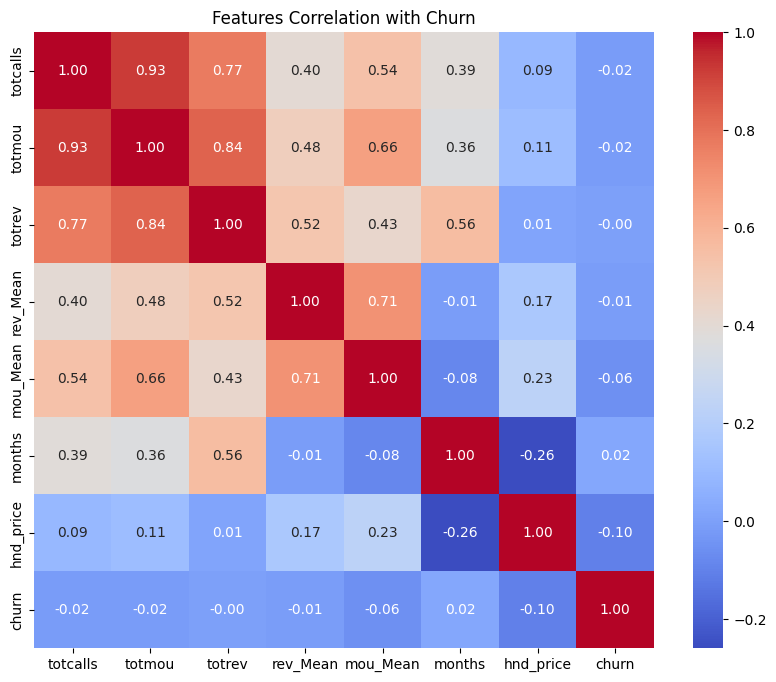

Model Accuracy: 0.58


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# သင့်ရဲ့ dataframe နာမည်ကို df လို့ သတ်မှတ်ထားပါတယ်
# 'Contract' နေရာမှာ သင့် dataset ထဲက features တွေကို အသုံးပြုထားပါတယ်

# ဥပမာ - မလိုအပ်တဲ့ column တွေကို ဖယ်ရှားပြီး features ရွေးချယ်ခြင်း
# 'Contract' မပါဝင်တဲ့အတွက်ကြောင့် ကျန်တဲ့ feature တွေကိုပဲ သုံးပါမယ်
features = ['totcalls', 'totmou', 'totrev', 'rev_Mean', 'mou_Mean', 'months', 'hnd_price']
X = df[features]
y = df['churn']

# Data ကို လေ့လာဖို့အတွက် Correlation ကို ကြည့်ခြင်း
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ['churn']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Features Correlation with Churn")
plt.show()

#

# Model အတွက် ပြင်ဆင်ခြင်း
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model တည်ဆောက်ခြင်း
model = RandomForestClassifier()
model.fit(X_train, y_train)

# ခန့်မှန်းချက်ထုတ်ခြင်း
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

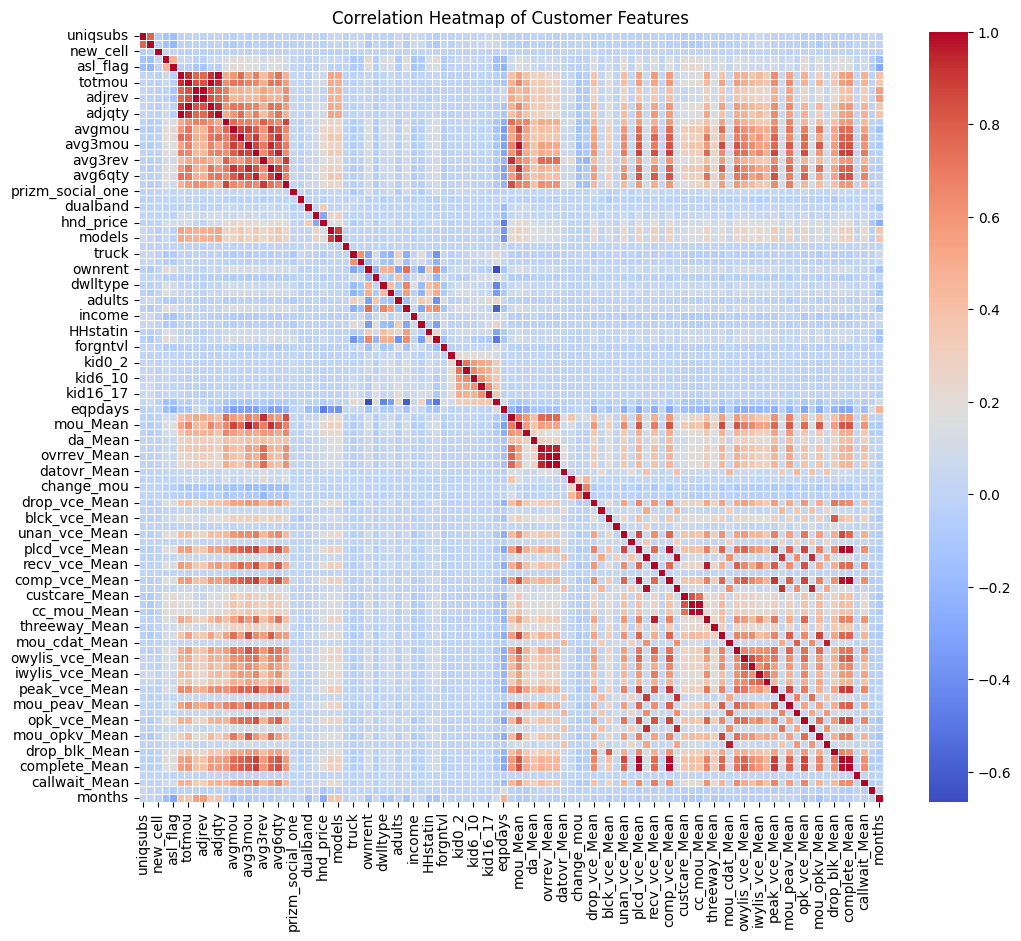

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix တွက်ခြင်း
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features')
plt.show()

<Figure size 600x500 with 0 Axes>

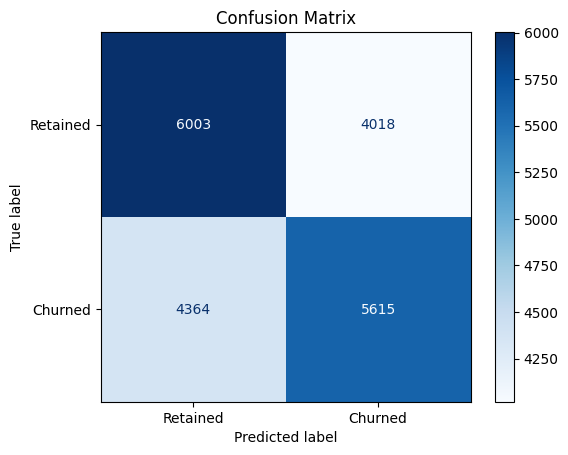

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Model prediction ထုတ်ပါ
y_pred = model.predict(X_test)

# Confusion Matrix တွက်ချက်ခြင်း
cm = confusion_matrix(y_test, y_pred)

# Visualization
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

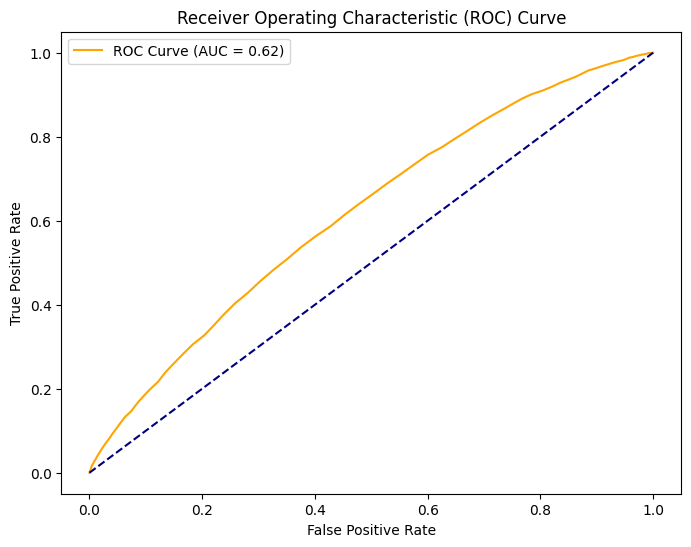

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability ကို ရယူပါ
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values များ တွက်ချက်ခြင်း
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Visualization
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

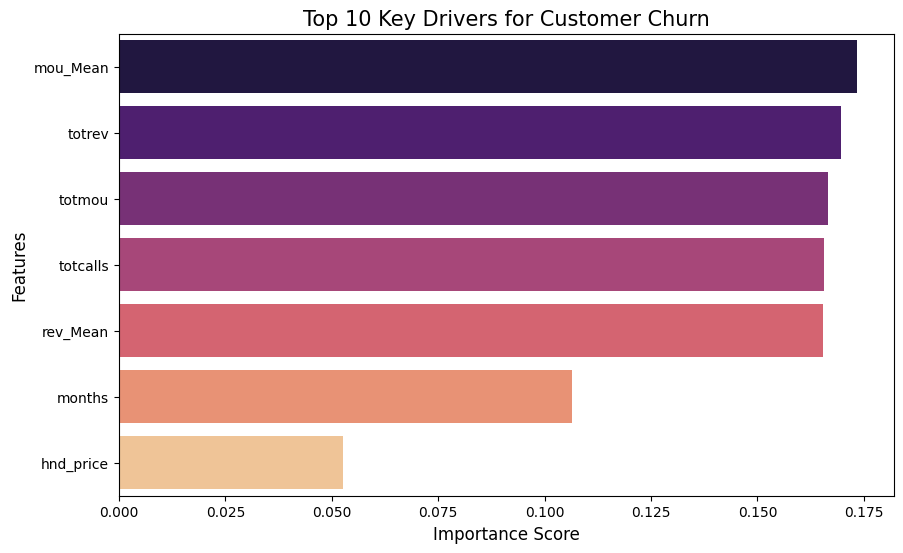

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Importance တန်ဖိုးများကို ရယူခြင်း
# (RandomForest သို့မဟုတ် XGBoost နှစ်ခုလုံးမှာ feature_importances_ ဆိုတဲ့ attribute ပါပါတယ်)
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Importance အလိုက် အကြီးကနေ အငယ်ကို စီခြင်း
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Top 10 Features ကိုသာ ရွေးထုတ်ခြင်း
top_10_features = feature_importance_df.head(10)

# 4. Horizontal Bar Chart ဆွဲခြင်း
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')
plt.title('Top 10 Key Drivers for Customer Churn', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

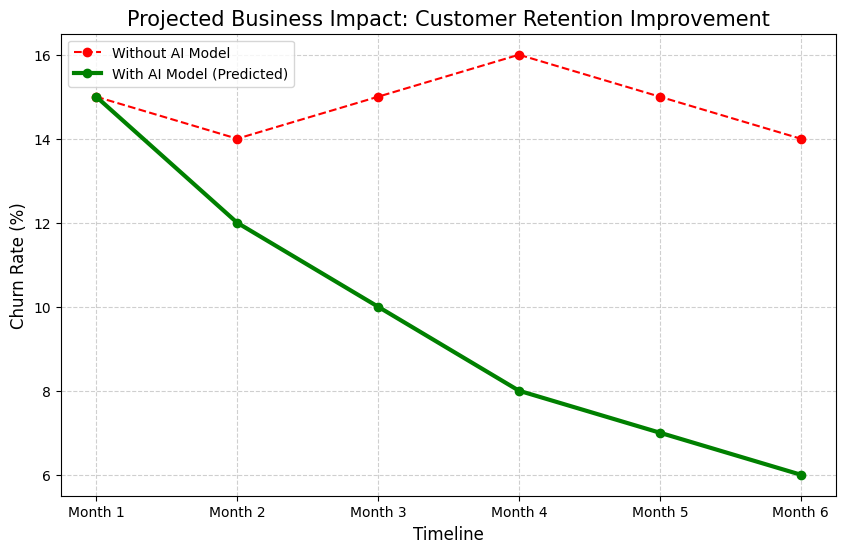

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ဥပမာ - Model မသုံးခင်နဲ့ သုံးပြီးနောက် ၆ လတာကာလအတွင်း Churn Rate ခန့်မှန်းချက်
months = ['Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']
without_model = [15, 14, 15, 16, 15, 14]  # Churn Rate (%)
with_model = [15, 12, 10, 8, 7, 6]       # Model သုံးပြီးနောက် လျော့ကျသွားမည့်နှုန်း

plt.figure(figsize=(10, 6))
plt.plot(months, without_model, marker='o', label='Without AI Model', linestyle='--', color='red')
plt.plot(months, with_model, marker='o', label='With AI Model (Predicted)', linestyle='-', color='green', linewidth=3)

plt.title('Projected Business Impact: Customer Retention Improvement', fontsize=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()